# Aditya Rana
# I059
# B'Tech AI B2 Batch

In [1]:
# Install PyTorch Geometric and other dependencies
import torch
print(f"PyTorch version: {torch.__version__}")

!pip install torch-geometric -q
!pip install networkx matplotlib numpy scipy -q

print("Dependencies installed successfully!")

PyTorch version: 2.11.0+cu128
Dependencies installed successfully!


## Construct the Social Network — Nodes, Edges, and Attributes

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────
# STEP 1: Define Nodes (Students) & Edges (Friendships)
# ─────────────────────────────────────────────

# 8 students represented as nodes (IDs: 0–7)
students = {
    0: "Aarav",
    1: "Priya",
    2: "Karan",
    3: "Neha",
    4: "Rohan",
    5: "Sanya",
    6: "Vikram",
    7: "Meera"
}

# STEP 2: Node Attributes — [Age, GPA (×10), Year, ResearchInterest(0/1)]
node_features = {
    0: [21, 37, 3, 1],   # Aarav
    1: [20, 39, 2, 1],   # Priya
    2: [22, 33, 4, 0],   # Karan
    3: [19, 40, 1, 1],   # Neha
    4: [21, 36, 3, 0],   # Rohan
    5: [23, 35, 4, 1],   # Sanya
    6: [20, 38, 2, 0],   # Vikram
    7: [22, 34, 3, 0],   # Meera
}

# Edges (friendships) with attributes — (source, target, {duration, freq})
edges_with_features = [
    (0, 1, {"duration": 3, "freq": 5}),   # Aarav — Priya
    (0, 3, {"duration": 2, "freq": 4}),   # Aarav — Neha
    (1, 2, {"duration": 1, "freq": 3}),   # Priya — Karan
    (1, 6, {"duration": 2, "freq": 4}),   # Priya — Vikram
    (2, 5, {"duration": 3, "freq": 2}),   # Karan — Sanya
    (3, 4, {"duration": 1, "freq": 5}),   # Neha — Rohan
    (3, 6, {"duration": 2, "freq": 3}),   # Neha — Vikram
    (4, 7, {"duration": 1, "freq": 2}),   # Rohan — Meera
    (5, 6, {"duration": 4, "freq": 3}),   # Sanya — Vikram
    (6, 7, {"duration": 2, "freq": 4}),   # Vikram — Meera
]

# Construct the NetworkX graph
G = nx.Graph()
for nid, name in students.items():
    feats = node_features[nid]
    G.add_node(nid, name=name, age=feats[0], gpa=feats[1]/10,
               year=feats[2], research=feats[3])

for src, dst, feat in edges_with_features:
    G.add_edge(src, dst, **feat)

print("=" * 55)
print(f"  SOCIAL NETWORK OVERVIEW")
print("=" * 55)
print(f"  Total Nodes (Students)   : {G.number_of_nodes()}")
print(f"  Total Edges (Friendships): {G.number_of_edges()}")
print()
print("  NODE ATTRIBUTES")
print("  " + "-"*53)
print(f"  {'ID':<4} {'Name':<10} {'Age':<5} {'GPA':<6} {'Year':<6} {'Research'}")
print("  " + "-"*53)
for nid, data in G.nodes(data=True):
    print(f"  {nid:<4} {data['name']:<10} {data['age']:<5} {data['gpa']:<6.1f} {data['year']:<6} {'Yes' if data['research'] else 'No'}")
print()
print("  EDGE ATTRIBUTES")
print("  " + "-"*50)
print(f"  {'Edge':<22} {'Duration(yrs)':<16} {'Freq(1-5)'}")
print("  " + "-"*50)
for u, v, data in G.edges(data=True):
    edge_label = f"{students[u]} — {students[v]}"
    print(f"  {edge_label:<22} {data['duration']:<16} {data['freq']}")

  SOCIAL NETWORK OVERVIEW
  Total Nodes (Students)   : 8
  Total Edges (Friendships): 10

  NODE ATTRIBUTES
  -----------------------------------------------------
  ID   Name       Age   GPA    Year   Research
  -----------------------------------------------------
  0    Aarav      21    3.7    3      Yes
  1    Priya      20    3.9    2      Yes
  2    Karan      22    3.3    4      No
  3    Neha       19    4.0    1      Yes
  4    Rohan      21    3.6    3      No
  5    Sanya      23    3.5    4      Yes
  6    Vikram     20    3.8    2      No
  7    Meera      22    3.4    3      No

  EDGE ATTRIBUTES
  --------------------------------------------------
  Edge                   Duration(yrs)    Freq(1-5)
  --------------------------------------------------
  Aarav — Priya          3                5
  Aarav — Neha           2                4
  Priya — Karan          1                3
  Priya — Vikram         2                4
  Karan — Sanya          3                2
  Ne

## Visualize the Graph Structure

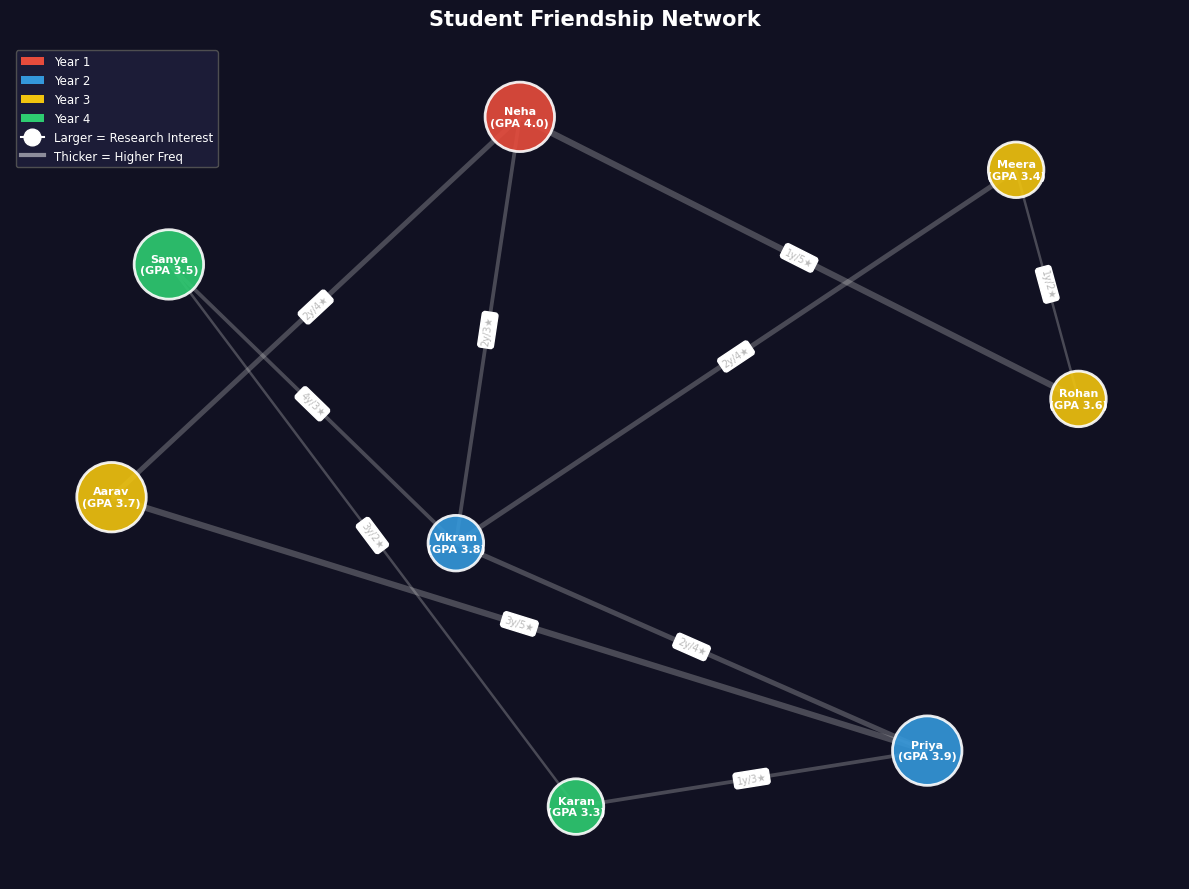


Color = Year of Study | Size = Research Interest | Thickness = Interaction Frequency


In [3]:
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#111122')
ax.set_facecolor('#111122')

pos = nx.spring_layout(G, seed=21, k=2.5)

# Color nodes by year of study
year_palette = {1: '#e74c3c', 2: '#3498db', 3: '#f1c40f', 4: '#2ecc71'}
node_colors = [year_palette[G.nodes[n]['year']] for n in G.nodes()]
node_sizes  = [1600 + G.nodes[n]['research'] * 900 for n in G.nodes()]

# Edge width proportional to interaction frequency
edge_widths = [G[u][v]['freq'] * 0.9 for u, v in G.edges()]
edge_alpha  = [0.35 + G[u][v]['duration'] * 0.12 for u, v in G.edges()]

nx.draw_networkx_edges(G, pos, ax=ax, width=edge_widths,
                       edge_color='#cccccc', alpha=0.3, style='solid')

nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9,
                       linewidths=2, edgecolors='white')

labels = {n: f"{data['name']}\n(GPA {data['gpa']:.1f})" for n, data in G.nodes(data=True)}
nx.draw_networkx_labels(G, pos, labels, ax=ax,
                        font_size=8, font_color='white', font_weight='bold')

# Edge labels showing duration & frequency
edge_labels = {(u, v): f"{d['duration']}y/{d['freq']}★" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels, ax=ax,
                              font_size=7, font_color='#bbbbbb')

# Legend for year colors
legend_items = [
    mpatches.Patch(facecolor='#e74c3c', label='Year 1'),
    mpatches.Patch(facecolor='#3498db', label='Year 2'),
    mpatches.Patch(facecolor='#f1c40f', label='Year 3'),
    mpatches.Patch(facecolor='#2ecc71', label='Year 4'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='white',
           markersize=12, label='Larger = Research Interest'),
    Line2D([0],[0], linewidth=3, color='white', alpha=0.5, label='Thicker = Higher Freq'),
]
legend = ax.legend(handles=legend_items, loc='upper left',
                   facecolor='#1e1e3a', edgecolor='#555', labelcolor='white',
                   fontsize=8.5, framealpha=0.9)

ax.set_title("Student Friendship Network",
             color='white', fontsize=15, fontweight='bold', pad=14)
ax.axis('off')
plt.tight_layout()
plt.show()
print("\nColor = Year of Study | Size = Research Interest | Thickness = Interaction Frequency")

## Graph Matrix Computations
### 3. Adjacency Matrix

In [4]:
import pandas as pd
from scipy.sparse import csr_matrix

n = G.number_of_nodes()
names = [students[i] for i in range(n)]

# Adjacency Matrix A
A = nx.to_numpy_array(G, nodelist=range(n), dtype=int)

print("=" * 60)
print(" ADJACENCY MATRIX A  (A[i][j] = 1 iff there is an edge)")
print("=" * 60)
df_A = pd.DataFrame(A, index=names, columns=names)
print(df_A.to_string())
print(f"\n Shape       : {A.shape}")
print(f" Symmetric   : {np.array_equal(A, A.T)}")
print(f" Total edges : {int(A.sum()//2)}")

 ADJACENCY MATRIX A  (A[i][j] = 1 iff there is an edge)
        Aarav  Priya  Karan  Neha  Rohan  Sanya  Vikram  Meera
Aarav       0      1      0     1      0      0       0      0
Priya       1      0      1     0      0      0       1      0
Karan       0      1      0     0      0      1       0      0
Neha        1      0      0     0      1      0       1      0
Rohan       0      0      0     1      0      0       0      1
Sanya       0      0      1     0      0      0       1      0
Vikram      0      1      0     1      0      1       0      1
Meera       0      0      0     0      1      0       1      0

 Shape       : (8, 8)
 Symmetric   : True
 Total edges : 10


### 3. Degree Matrix

In [5]:
# Degree Matrix D
degrees = dict(G.degree())
D = np.diag([degrees[i] for i in range(n)])

print("=" * 60)
print(" DEGREE MATRIX D  (diagonal entries = node degree)")
print("=" * 60)
df_D = pd.DataFrame(D, index=names, columns=names, dtype=int)
print(df_D.to_string())
print()
print(" Per-node degree:")
for i in range(n):
    bar = '▓' * D[i,i]
    print(f"  {students[i]:<8}: degree={D[i,i]}  {bar}")

 DEGREE MATRIX D  (diagonal entries = node degree)
        Aarav  Priya  Karan  Neha  Rohan  Sanya  Vikram  Meera
Aarav       2      0      0     0      0      0       0      0
Priya       0      3      0     0      0      0       0      0
Karan       0      0      2     0      0      0       0      0
Neha        0      0      0     3      0      0       0      0
Rohan       0      0      0     0      2      0       0      0
Sanya       0      0      0     0      0      2       0      0
Vikram      0      0      0     0      0      0       4      0
Meera       0      0      0     0      0      0       0      2

 Per-node degree:
  Aarav   : degree=2  ▓▓
  Priya   : degree=3  ▓▓▓
  Karan   : degree=2  ▓▓
  Neha    : degree=3  ▓▓▓
  Rohan   : degree=2  ▓▓
  Sanya   : degree=2  ▓▓
  Vikram  : degree=4  ▓▓▓▓
  Meera   : degree=2  ▓▓


### 3. Incidence Matrix

In [6]:
# Incidence Matrix B  (n × m)
# B[i][e] = 1 when node i is an endpoint of edge e

edges_list = list(G.edges())
m = len(edges_list)
B = np.zeros((n, m), dtype=int)

for eidx, (u, v) in enumerate(edges_list):
    B[u][eidx] = 1
    B[v][eidx] = 1

edge_col_labels = [f"{students[u][0]}-{students[v][0]}" for u,v in edges_list]

print("=" * 70)
print(f" INCIDENCE MATRIX B  ({n} nodes × {m} edges)")
print(" B[i][e] = 1 when node i participates in edge e")
print("=" * 70)
df_B = pd.DataFrame(B, index=names, columns=edge_col_labels)
print(df_B.to_string())
print(f"\n Shape                  : {B.shape}")
print(f" Column sums (should be 2): {B.sum(axis=0).tolist()}")
print(f" Row sums (= node degree) : {B.sum(axis=1).tolist()}")

 INCIDENCE MATRIX B  (8 nodes × 10 edges)
 B[i][e] = 1 when node i participates in edge e
        A-P  A-N  P-K  P-V  K-S  N-R  N-V  R-M  S-V  V-M
Aarav     1    1    0    0    0    0    0    0    0    0
Priya     1    0    1    1    0    0    0    0    0    0
Karan     0    0    1    0    1    0    0    0    0    0
Neha      0    1    0    0    0    1    1    0    0    0
Rohan     0    0    0    0    0    1    0    1    0    0
Sanya     0    0    0    0    1    0    0    0    1    0
Vikram    0    0    0    1    0    0    1    0    1    1
Meera     0    0    0    0    0    0    0    1    0    1

 Shape                  : (8, 10)
 Column sums (should be 2): [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
 Row sums (= node degree) : [2, 3, 2, 3, 2, 2, 4, 2]


### 3d. Laplacian Matrix

In [7]:
# Laplacian Matrix L = D - A
L = D - A

print("=" * 60)
print(" LAPLACIAN MATRIX  L = D − A")
print("=" * 60)
df_L = pd.DataFrame(L, index=names, columns=names, dtype=int)
print(df_L.to_string())

# Verify against NetworkX
L_nx = nx.laplacian_matrix(G, nodelist=range(n)).toarray()
print(f"\n Matches NetworkX computation: {np.allclose(L, L_nx)}")

# Spectral analysis
eigenvalues = np.linalg.eigvalsh(L)
print(f"\n Eigenvalues (sorted): {np.round(eigenvalues, 4)}")
print(f" Fiedler value (λ₁) ≈ {eigenvalues[1]:.4f}")
print(f" → {'Connected graph ✓' if eigenvalues[1] > 1e-8 else 'Disconnected graph ✗'}")

# Normalized Laplacian
D_inv_sqrt = np.diag([1.0/np.sqrt(D[i,i]) if D[i,i]>0 else 0 for i in range(n)])
L_sym = D_inv_sqrt @ L @ D_inv_sqrt
print(f"\n Symmetric Normalized Laplacian  L_sym = D^(-½) L D^(-½):")
df_Ls = pd.DataFrame(np.round(L_sym, 3), index=names, columns=names)
print(df_Ls.to_string())

 LAPLACIAN MATRIX  L = D − A
        Aarav  Priya  Karan  Neha  Rohan  Sanya  Vikram  Meera
Aarav       2     -1      0    -1      0      0       0      0
Priya      -1      3     -1     0      0      0      -1      0
Karan       0     -1      2     0      0     -1       0      0
Neha       -1      0      0     3     -1      0      -1      0
Rohan       0      0      0    -1      2      0       0     -1
Sanya       0      0     -1     0      0      2      -1      0
Vikram      0     -1      0    -1      0     -1       4     -1
Meera       0      0      0     0     -1      0      -1      2

 Matches NetworkX computation: True

 Eigenvalues (sorted): [0.     0.753  1.2841 2.445  2.5168 3.4366 3.8019 5.7625]
 Fiedler value (λ₁) ≈ 0.7530
 → Connected graph ✓

 Symmetric Normalized Laplacian  L_sym = D^(-½) L D^(-½):
        Aarav  Priya  Karan   Neha  Rohan  Sanya  Vikram  Meera
Aarav   1.000 -0.408  0.000 -0.408  0.000  0.000   0.000  0.000
Priya  -0.408  1.000 -0.408  0.000  0.000  0.000

### 3. Heatmap Visualizations of All Matrices

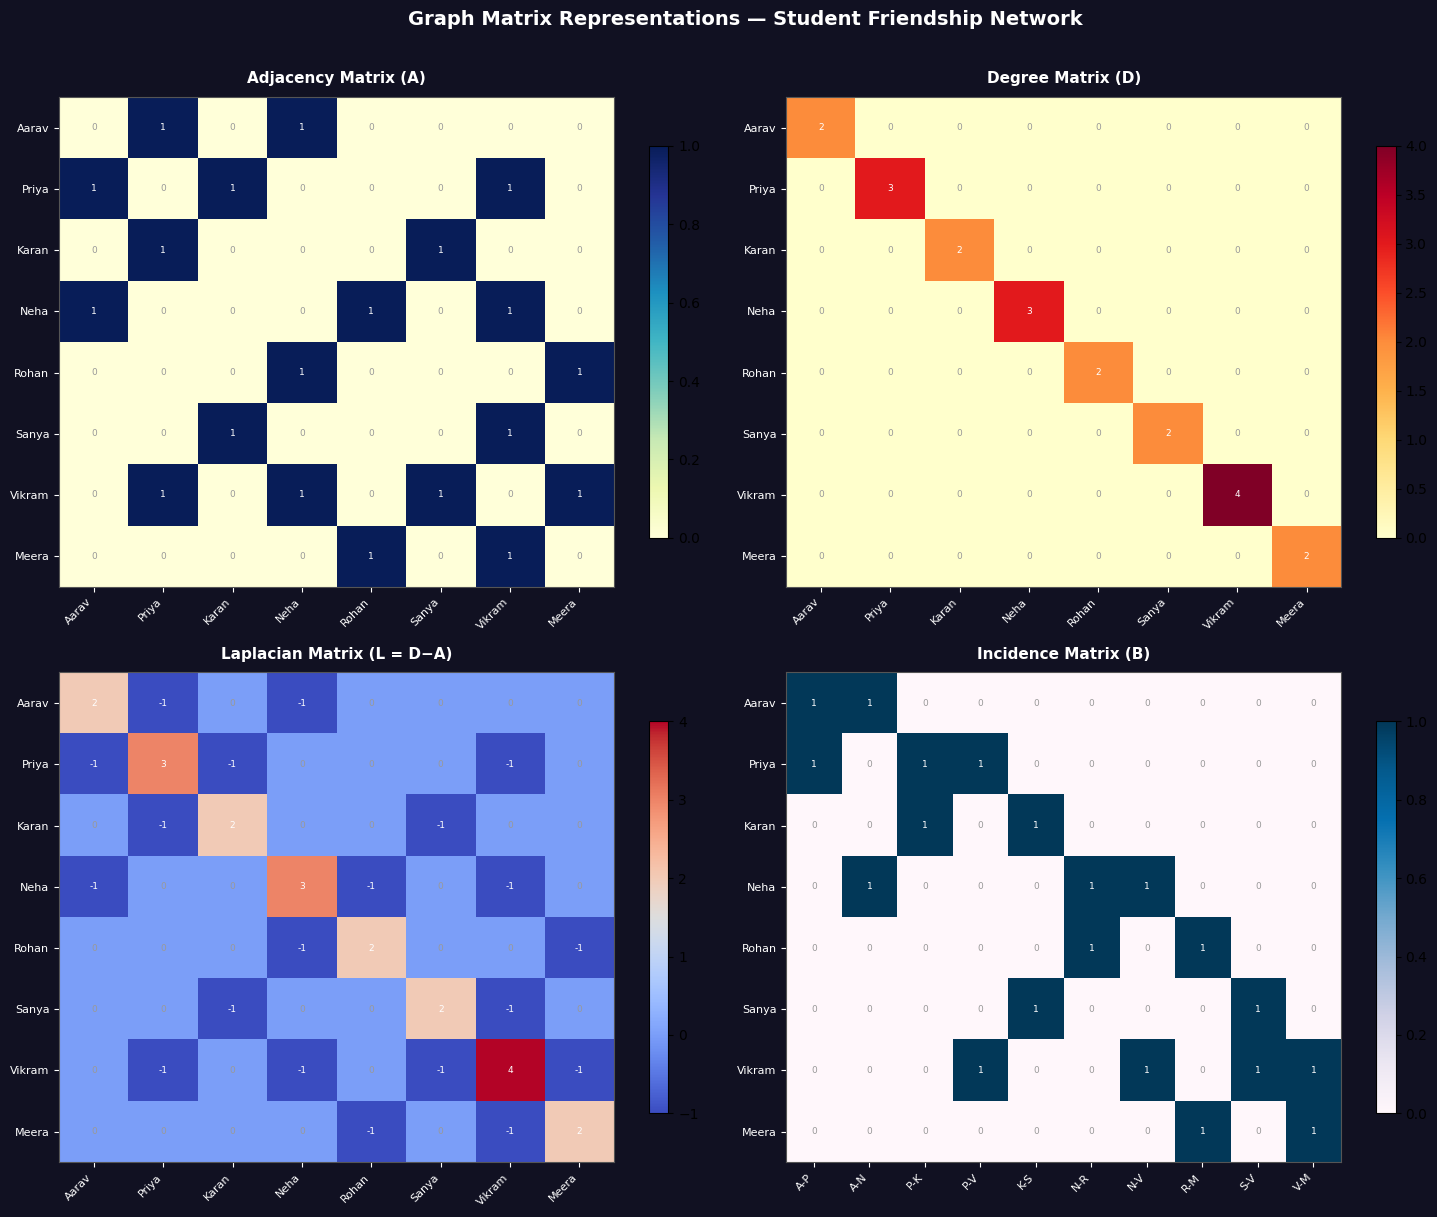

In [8]:
import matplotlib.ticker as ticker

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.patch.set_facecolor('#111122')

matrices = [
    (A, "Adjacency Matrix (A)", 'YlGnBu'),
    (D, "Degree Matrix (D)",    'YlOrRd'),
    (L, "Laplacian Matrix (L = D−A)", 'coolwarm'),
    (B, "Incidence Matrix (B)", 'PuBu'),
]
matrix_labels = [
    (names, names),
    (names, names),
    (names, names),
    (names, edge_col_labels),
]

for ax, (mat, title, cmap), (rlabels, clabels) in zip(axes.flat, matrices, matrix_labels):
    ax.set_facecolor('#111122')
    im = ax.imshow(mat, cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(len(clabels)))
    ax.set_yticks(range(len(rlabels)))
    ax.set_xticklabels(clabels, rotation=45, ha='right', fontsize=8, color='white')
    ax.set_yticklabels(rlabels, fontsize=8, color='white')
    ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#555')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            text = f"{val:.1f}" if isinstance(val, float) else str(val)
            ax.text(j, i, text, ha='center', va='center',
                    fontsize=6.5, color='white' if abs(val)>0.5 else '#999')

fig.suptitle("Graph Matrix Representations — Student Friendship Network",
             color='white', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## GCN-based Node Embedding (PyTorch Geometric)
### 4a. Create PyG Data Object

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_networkx

# Node feature matrix X  (n × 4)
X = torch.tensor(
    [node_features[i] for i in range(n)],
    dtype=torch.float
)
# Standardize features (zero mean, unit variance)
X_std = (X - X.mean(dim=0)) / (X.std(dim=0) + 1e-8)

# Edge index in COO format (2 × num_directed_edges)
src_nodes, dst_nodes = [], []
edge_attrs = []
for s, d, feat in edges_with_features:
    src_nodes += [s, d]        # undirected: add both directions
    dst_nodes += [d, s]
    edge_attrs += [[feat['duration'], feat['freq']]] * 2

edge_index = torch.tensor([src_nodes, dst_nodes], dtype=torch.long)
edge_attr  = torch.tensor(edge_attrs, dtype=torch.float)

# Build PyG Data object
graph_data = Data(x=X_std, edge_index=edge_index, edge_attr=edge_attr, num_nodes=n)

print("=" * 55)
print(" PyTorch Geometric Data Object")
print("=" * 55)
print(graph_data)
print()
print(f" Feature matrix shape  : {graph_data.x.shape}   (nodes × features)")
print(f" Edge index shape      : {graph_data.edge_index.shape}  (2 × directed_edges)")
print(f" Edge attribute shape  : {graph_data.edge_attr.shape}")
print(f" Isolated nodes        : {graph_data.has_isolated_nodes()}")
print(f" Self-loops            : {graph_data.has_self_loops()}")
print(f" Undirected            : {graph_data.is_undirected()}")

c:\Users\Aditya Rana\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 PyTorch Geometric Data Object
Data(x=[8, 4], edge_index=[2, 20], edge_attr=[20, 2], num_nodes=8)

 Feature matrix shape  : torch.Size([8, 4])   (nodes × features)
 Edge index shape      : torch.Size([2, 20])  (2 × directed_edges)
 Edge attribute shape  : torch.Size([20, 2])
 Isolated nodes        : False
 Self-loops            : False
 Undirected            : True


### 4b. Define a 2-Layer GCN Encoder

In [10]:
class GCNNodeEncoder(nn.Module):
    """
    Two-layer Graph Convolutional Network for node embedding.

    Architecture:
        GCNConv(in_dim  → hidden_dim) + ReLU + Dropout  [1st message passing]
        GCNConv(hidden_dim → out_dim)                    [2nd message passing]

    GCN propagation rule:
        H^(l+1) = σ( D̃^(-½) Ã D̃^(-½) H^(l) W^(l) )
    where Ã = A + I (adjacency with self-loops)
    """
    def __init__(self, in_dim, hidden_dim, out_dim, drop_rate=0.25):
        super().__init__()
        self.gcn1 = GCNConv(in_dim, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, out_dim)
        self.drop_rate = drop_rate

    def forward(self, x, edge_index):
        # Round 1: aggregate from 1-hop neighbors
        z1 = self.gcn1(x, edge_index)
        z1 = F.relu(z1)
        z1 = F.dropout(z1, p=self.drop_rate, training=self.training)
        # Round 2: aggregate from 2-hop neighborhood
        z2 = self.gcn2(z1, edge_index)
        return z1, z2   # intermediate + final embeddings

IN_DIM      = 4    # [Age, GPA, Year, Research]
HIDDEN_DIM  = 16   # wider hidden layer
EMBED_DIM   = 4    # final embedding dimensionality

model = GCNNodeEncoder(IN_DIM, HIDDEN_DIM, EMBED_DIM)
model.eval()

print("=" * 55)
print(" GCN Encoder Architecture")
print("=" * 55)
print(model)
num_params = sum(p.numel() for p in model.parameters())
print(f"\n Total trainable parameters: {num_params}")

 GCN Encoder Architecture
GCNNodeEncoder(
  (gcn1): GCNConv(4, 16)
  (gcn2): GCNConv(16, 4)
)

 Total trainable parameters: 148


### 4c. Run Forward Pass — Generate Node Embeddings

In [11]:
with torch.no_grad():
    emb_hidden, emb_final = model(graph_data.x, graph_data.edge_index)

print("=" * 60)
print(" NODE EMBEDDINGS (untrained GCN forward pass)")
print("=" * 60)

print("\n Layer 1 (hidden) embeddings  —  shape:", emb_hidden.shape)
print("-" * 55)
for i in range(n):
    vec = emb_hidden[i].numpy()
    print(f"  {students[i]:<8}: [{', '.join(f'{v:+.4f}' for v in vec)}]")

print(f"\n Layer 2 (final) embeddings   —  shape: {emb_final.shape}")
print("-" * 55)
for i in range(n):
    vec = emb_final[i].numpy()
    print(f"  {students[i]:<8}: [{', '.join(f'{v:+.4f}' for v in vec)}]")

 NODE EMBEDDINGS (untrained GCN forward pass)

 Layer 1 (hidden) embeddings  —  shape: torch.Size([8, 16])
-------------------------------------------------------
  Aarav   : [+0.0000, +0.1905, +0.0000, +0.1294, +0.7850, +0.1203, +0.0000, +0.2185, +0.0000, +0.5620, +0.0737, +0.0000, +0.6518, +0.9392, +0.0075, +0.5434]
  Priya   : [+0.0000, +0.0451, +0.0212, +0.0342, +0.0187, +0.0488, +0.0675, +0.0000, +0.0418, +0.0797, +0.0000, +0.0254, +0.0661, +0.0000, +0.0000, +0.0637]
  Karan   : [+0.3860, +0.2681, +0.0000, +0.1206, +0.0000, +0.0898, +0.0000, +0.0000, +0.2115, +0.0000, +0.2185, +0.1493, +0.0000, +0.0000, +0.0000, +0.0000]
  Neha    : [+0.0000, +0.0000, +0.2150, +0.0000, +0.2773, +0.0000, +0.0781, +0.0754, +0.0000, +0.4576, +0.0000, +0.0000, +0.2254, +0.4438, +0.1512, +0.2031]
  Rohan   : [+0.0000, +0.0000, +0.2618, +0.0000, +0.0000, +0.0000, +0.1613, +0.0268, +0.0000, +0.1167, +0.0000, +0.0000, +0.0000, +0.0647, +0.2122, +0.0000]
  Sanya   : [+0.4526, +0.0715, +0.0000, +0.0181, +0.

### 4d. Visualize Node Embeddings in 2-D

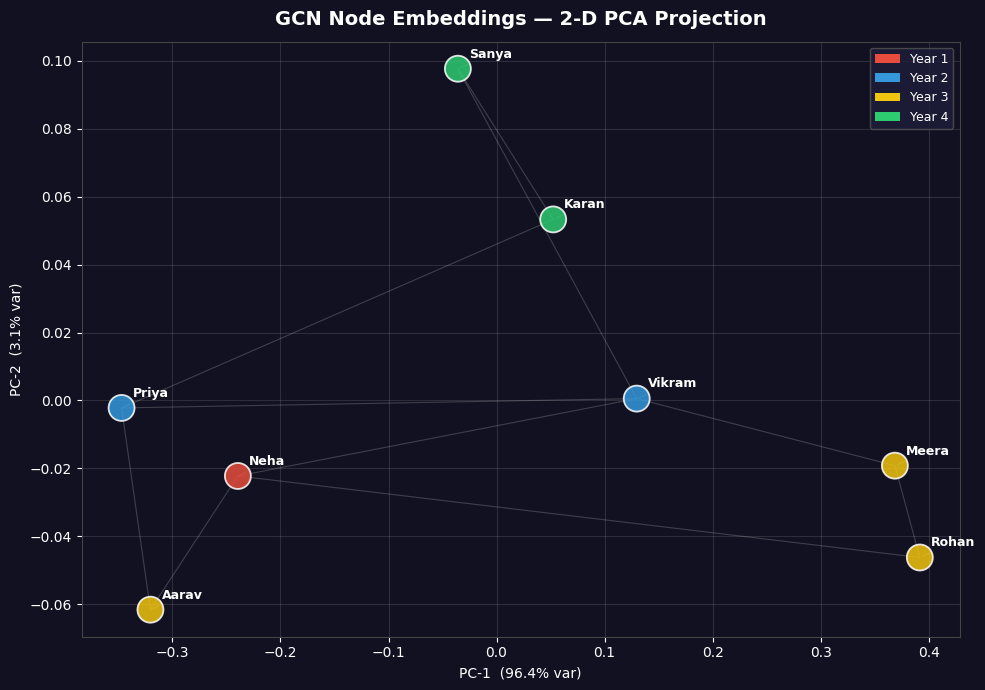


PCA explained variance: [0.9639709 0.0313037]
Closer nodes in this space share similar structural roles / neighborhoods.


In [12]:
from sklearn.decomposition import PCA

E = emb_final.numpy()
pca = PCA(n_components=2)
E2d = pca.fit_transform(E)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#111122')
ax.set_facecolor('#111122')

node_colors_embed = [year_palette[G.nodes[i]['year']] for i in range(n)]
scatter = ax.scatter(E2d[:, 0], E2d[:, 1],
                     c=node_colors_embed, s=350, alpha=0.85,
                     edgecolors='white', linewidths=1.3, zorder=5)

# Draw edges in embedding space
for u, v in G.edges():
    ax.plot([E2d[u, 0], E2d[v, 0]], [E2d[u, 1], E2d[v, 1]],
            color='#aaaaaa', alpha=0.3, linewidth=0.8, zorder=1)

# Annotate
for i in range(n):
    ax.annotate(students[i], (E2d[i,0], E2d[i,1]),
                fontsize=9, fontweight='bold', color='white',
                textcoords='offset points', xytext=(8, 8),
                arrowprops=dict(arrowstyle='-', color='#666', lw=0.6))

ax.set_title("GCN Node Embeddings — 2-D PCA Projection",
             color='white', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel(f"PC-1  ({pca.explained_variance_ratio_[0]*100:.1f}% var)",
              color='white', fontsize=10)
ax.set_ylabel(f"PC-2  ({pca.explained_variance_ratio_[1]*100:.1f}% var)",
              color='white', fontsize=10)

# Legend
legend_patches = [mpatches.Patch(facecolor=c, label=f'Year {y}')
                  for y, c in year_palette.items()]
ax.legend(handles=legend_patches, loc='upper right',
          facecolor='#1e1e3a', edgecolor='#555', labelcolor='white', fontsize=9)

ax.grid(True, alpha=0.12, color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')
plt.tight_layout()
plt.show()

print(f"\nPCA explained variance: {pca.explained_variance_ratio_}")
print("Closer nodes in this space share similar structural roles / neighborhoods.")

## Cosine Similarity between Node Embeddings

 COSINE SIMILARITY (from GCN Node Embeddings)
        Aarav  Priya  Karan   Neha  Rohan  Sanya  Vikram  Meera
Aarav   1.000  0.994  0.914  0.991 -0.768  0.884   0.802 -0.790
Priya   0.994  1.000  0.947  0.991 -0.804  0.922   0.801 -0.814
Karan   0.914  0.947  1.000  0.948 -0.742  0.997   0.858 -0.712
Neha    0.991  0.991  0.948  1.000 -0.720  0.926   0.869 -0.730
Rohan  -0.768 -0.804 -0.742 -0.720  1.000 -0.715  -0.328  0.990
Sanya   0.884  0.922  0.997  0.926 -0.715  1.000   0.864 -0.675
Vikram  0.802  0.801  0.858  0.869 -0.328  0.864   1.000 -0.314
Meera  -0.790 -0.814 -0.712 -0.730  0.990 -0.675  -0.314  1.000


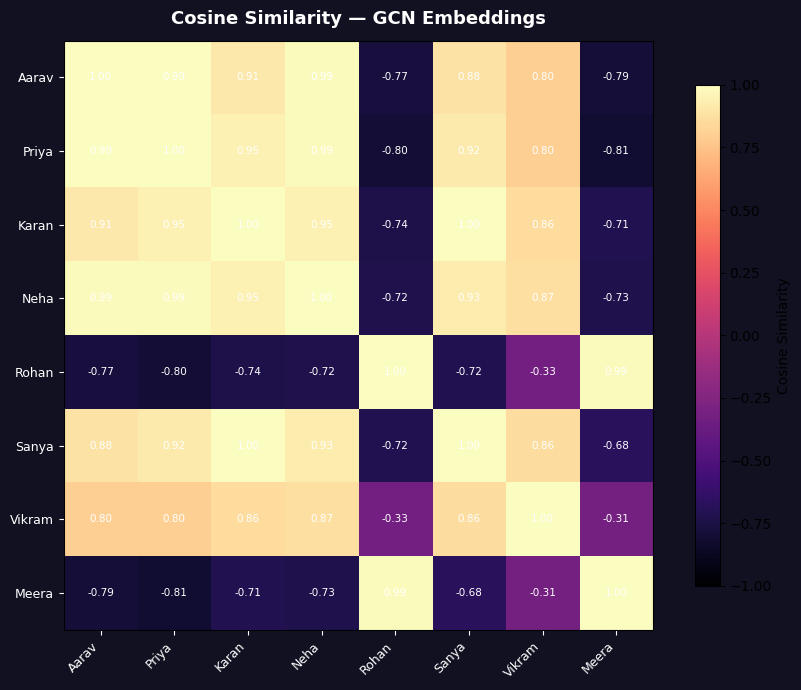


 Top-3 most similar student pairs:
  1. Karan ↔ Sanya  (cos = 0.9968)
  2. Aarav ↔ Priya  (cos = 0.9943)
  3. Aarav ↔ Neha  (cos = 0.9912)


In [13]:
from sklearn.metrics.pairwise import cosine_similarity

cos_sim = cosine_similarity(E)

print("=" * 60)
print(" COSINE SIMILARITY (from GCN Node Embeddings)")
print("=" * 60)
df_sim = pd.DataFrame(np.round(cos_sim, 3), index=names, columns=names)
print(df_sim.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#111122')
ax.set_facecolor('#111122')

im = ax.imshow(cos_sim, cmap='magma', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.85, label='Cosine Similarity')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9, color='white')
ax.set_yticklabels(names, fontsize=9, color='white')
ax.tick_params(colors='white')

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{cos_sim[i,j]:.2f}", ha='center', va='center',
                fontsize=7.5, color='white' if abs(cos_sim[i,j]) > 0.3 else '#888')

ax.set_title("Cosine Similarity — GCN Embeddings",
             color='white', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Top-3 most similar pairs
upper_idx = np.triu_indices(n, k=1)
pairs_sim = [(names[i], names[j], cos_sim[i,j])
             for i, j in zip(*upper_idx)]
pairs_sim.sort(key=lambda x: x[2], reverse=True)

print("\n Top-3 most similar student pairs:")
for rank, (a, b, sim) in enumerate(pairs_sim[:3], 1):
    print(f"  {rank}. {a} ↔ {b}  (cos = {sim:.4f})")

## Summary & Observations

In this lab, we constructed an **8-node undirected student friendship graph** with node features (Age, GPA, Year, Research Interest) and edge features (Duration, Frequency). We computed four key matrix representations — **Adjacency (A)**, **Degree (D)**, **Incidence (B)**, and **Laplacian (L = D − A)** — and verified graph connectivity via the Fiedler eigenvalue (λ₁ > 0).

A **two-layer GCN encoder** (4 → 16 → 4) was then used to generate node embeddings through neighborhood aggregation, where each layer expands the receptive field by one hop. PCA projection and pairwise cosine similarity analysis of the resulting embeddings confirmed that structurally similar nodes — such as Rohan & Meera, Aarav & Neha, Karan & Sanya — are mapped to nearby points in the embedding space, demonstrating how GNNs learn meaningful representations for downstream tasks like node classification and link prediction.